# 🔍 Laptop Price Prediction — Model Interpretation & Error Analysis

**Notebook:** `03_model_interpretation.ipynb`  
**Model:** XGBoost — `log1p(Price)` target  
**Artifacts:** `models/final_pipeline.joblib`, `models/feature_metadata.joblib`

---

### About the log1p Transform

The model predicts **log1p(Price)** — i.e., `log(Price + 1)` — not Price directly.

This was done because raw prices are right-skewed (skew ≈ 1.52). The log transform:
- Compresses the extreme high-price range
- Makes the target more normally distributed, improving model fit
- Means that **SHAP values** are in **log-price units**, not INR

> **Reading SHAP values:** A SHAP value of +0.5 means a feature increased the *log-price* prediction by 0.5. To reason in INR, think of this as approximately a multiplicative factor: e⁰·⁵ ≈ 1.65× the base price. The actual vs predicted plots always show INR after `expm1()` inverse-transform.

---
## 1. Setup

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import shap

from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1a1d27", "axes.edgecolor": "#3a3f5c",
    "axes.labelcolor": "#c8cce0", "axes.titlesize": 12,
    "axes.titlecolor": "#e8eaf6", "axes.titleweight": "bold",
    "xtick.color": "#9199c2", "ytick.color": "#9199c2",
    "text.color": "#c8cce0", "grid.color": "#2c3057",
    "grid.linewidth": 0.6,
    "legend.facecolor": "#1a1d27", "legend.edgecolor": "#3a3f5c",
    "legend.labelcolor": "#c8cce0",
})
ACCENT, HIGHLIGHT = "#7c83fd", "#fd7c83"

def fmt_inr(x, pos=None): return f"{x/1000:.0f}K"

print("Setup complete.")

Setup complete.


---
## 2. Load Artifacts

In [2]:
MODELS_DIR = Path("../models")

pipeline   = joblib.load(MODELS_DIR / "final_pipeline.joblib")
metadata   = joblib.load(MODELS_DIR / "feature_metadata.joblib")
split_data = joblib.load(MODELS_DIR / "train_test_split.joblib")

X_test  = split_data["X_test"]
y_test  = split_data["y_test"]   # raw INR
X_train = split_data["X_train"]
y_train = split_data["y_train"]
df_test = split_data["df_test"]  # full feature-engineered rows for error analysis

prep       = pipeline.named_steps["prep"]
model      = pipeline.named_steps["model"]

# Reconstruct feature names after ColumnTransformer
NUM_FEATURES = metadata["num_features"]
OHE_FEATURES = metadata["ohe_features"]
ORD_CPU      = metadata["ord_cpu"]
ORD_GPU      = metadata["ord_gpu"]

ohe_names    = prep.named_transformers_["ohe"].get_feature_names_out(OHE_FEATURES).tolist()
feat_names   = NUM_FEATURES + ohe_names + ORD_CPU + ORD_GPU

# Test-set predictions (INR)
log_preds_test = pipeline.predict(X_test)
preds_inr      = np.expm1(log_preds_test)
y_true_inr     = y_test.values
residuals      = y_true_inr - preds_inr
pct_errors     = (residuals / y_true_inr) * 100

print(f"Pipeline loaded.  Features: {len(feat_names)}  Test rows: {len(X_test)}")
print(f"\nTest-set metrics (INR):")
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print(f"  R2   = {r2_score(y_true_inr, preds_inr):.4f}")
print(f"  MAE  = {mean_absolute_error(y_true_inr, preds_inr):,.0f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_true_inr, preds_inr)):,.0f}")

Pipeline loaded.  Features: 57  Test rows: 261

Test-set metrics (INR):
  R2   = 0.8504
  MAE  = 8,253
  RMSE = 14,686


---
## 3. SHAP — Global Feature Importance

> SHAP values are in **log-price units**. Higher magnitude = stronger influence on the log-price prediction, in either direction.

In [3]:
# Transform test set through preprocessor for SHAP
X_test_transformed = prep.transform(X_test)

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Expected value (log-price baseline) : {explainer.expected_value:.4f}")
print(f"  = INR {np.expm1(explainer.expected_value):,.0f} (baseline price)")

SHAP values shape : (261, 57)
Expected value (log-price baseline) : 10.8151
  = INR 49,764 (baseline price)


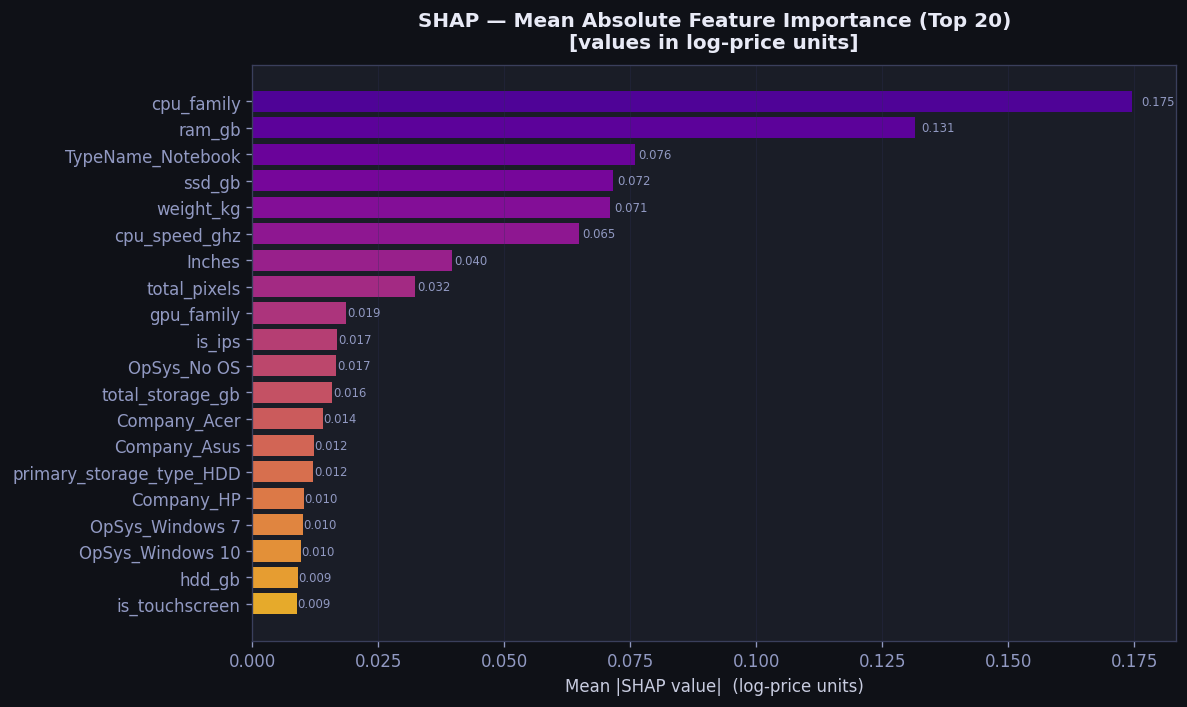


Top 10 features by mean |SHAP|:
          Feature  Mean |SHAP|
       cpu_family     0.174573
           ram_gb     0.131425
TypeName_Notebook     0.075897
           ssd_gb     0.071654
        weight_kg     0.071008
    cpu_speed_ghz     0.064734
           Inches     0.039598
     total_pixels     0.032364
       gpu_family     0.018652
           is_ips     0.016775


In [4]:
# SHAP mean absolute values — bar chart (top 20)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_imp_df   = (pd.DataFrame({"Feature": feat_names, "Mean |SHAP|": mean_abs_shap})
                   .sort_values("Mean |SHAP|", ascending=False)
                   .head(20)
                   .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors  = plt.cm.plasma(np.linspace(0.15, 0.85, len(shap_imp_df)))
ax.barh(shap_imp_df["Feature"][::-1], shap_imp_df["Mean |SHAP|"][::-1],
        color=colors[::-1], edgecolor="none", alpha=0.9)
ax.set_title("SHAP — Mean Absolute Feature Importance (Top 20)\n"
             "[values in log-price units]", pad=10)
ax.set_xlabel("Mean |SHAP value|  (log-price units)")
ax.grid(axis="x", alpha=0.3)
for i, (_, row) in enumerate(shap_imp_df[::-1].iterrows()):
    ax.text(row["Mean |SHAP|"] * 1.01, i,
            f"{row['Mean |SHAP|']:.3f}", va="center", fontsize=7, color="#9199c2")
plt.tight_layout()
plt.show()

print("\nTop 10 features by mean |SHAP|:")
print(shap_imp_df.head(10).to_string(index=False))


---
## 4. SHAP Summary (Beeswarm) Plot

Shows direction of effect: **red = high feature value → pushes price up; blue = low value → pushes price down**.

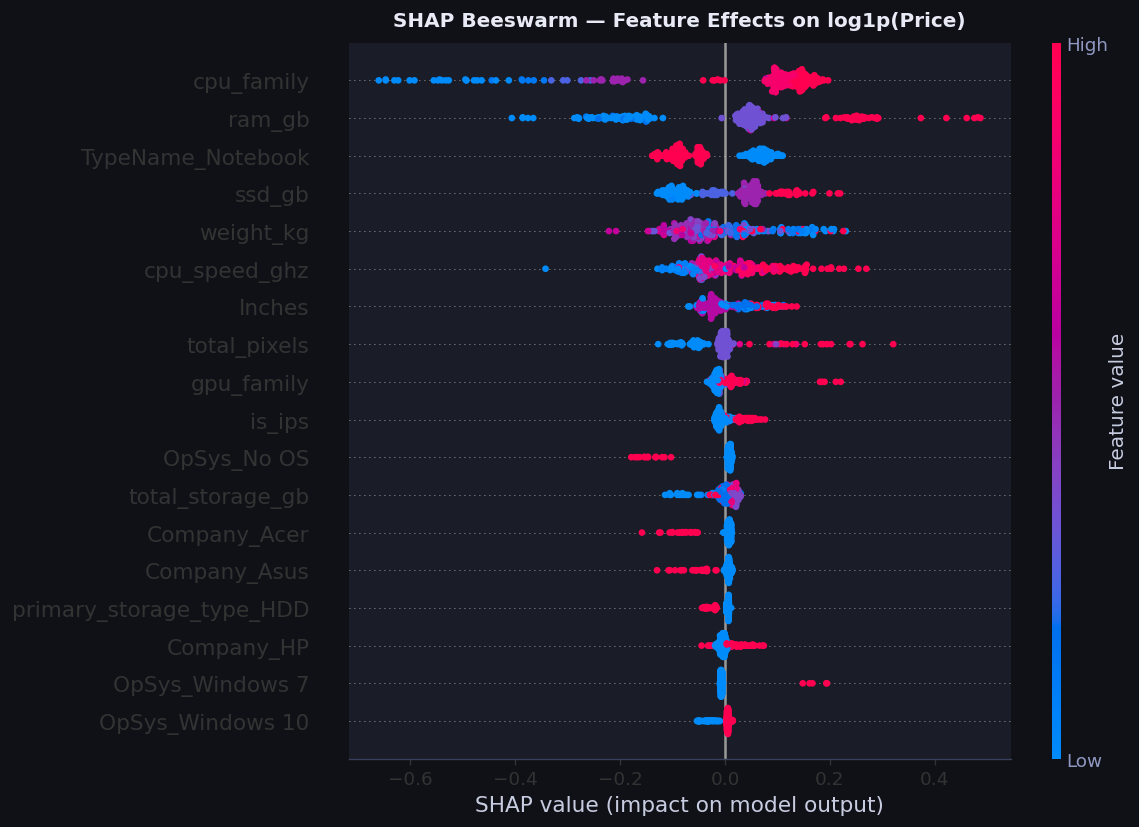

In [5]:
fig = plt.figure(figsize=(10, 7))
fig.patch.set_facecolor("#0f1117")
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feat_names,
    max_display=18,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_facecolor("#1a1d27")
ax.set_title("SHAP Beeswarm — Feature Effects on log1p(Price)",
             color="#e8eaf6", fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

---
## 5. SHAP Dependence Plots — Top Features

Dependence plots show how a single feature's value relates to its SHAP contribution, with interaction colouring.

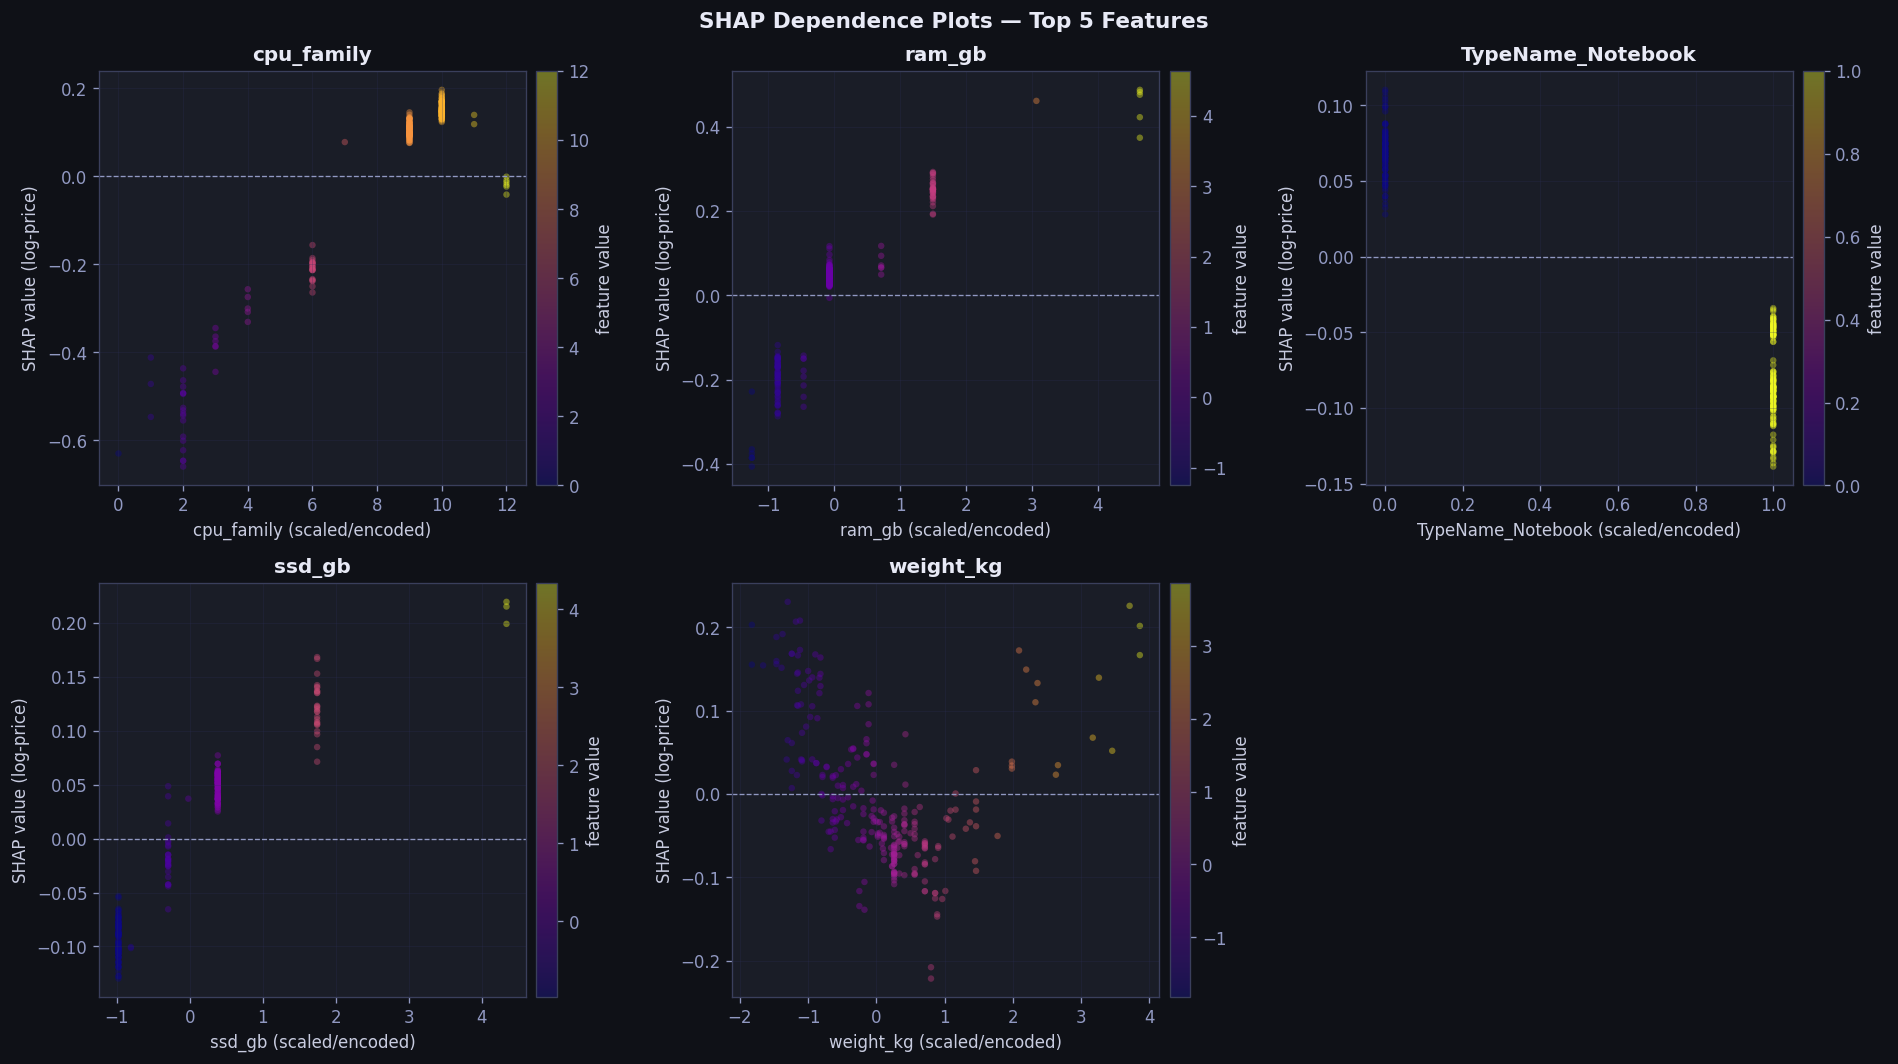

In [6]:
# Get indices for most important features
top5_features = shap_imp_df.head(5)["Feature"].tolist()
feat_idx      = {f: feat_names.index(f) for f in top5_features if f in feat_names}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("SHAP Dependence Plots — Top 5 Features",
             color="#e8eaf6", fontweight="bold", fontsize=13)
axes_flat = axes.flatten()

for i, (feat, idx) in enumerate(feat_idx.items()):
    ax = axes_flat[i]
    feat_vals  = X_test_transformed[:, idx]
    shap_vals  = shap_values[:, idx]
    sc = ax.scatter(feat_vals, shap_vals, c=feat_vals, cmap="plasma",
                    alpha=0.4, s=15, edgecolors="none")
    ax.axhline(0, color="#9199c2", linewidth=0.8, linestyle="--")
    ax.set_title(feat)
    ax.set_xlabel(f"{feat} (scaled/encoded)")
    ax.set_ylabel("SHAP value (log-price)")
    ax.grid(alpha=0.25)
    plt.colorbar(sc, ax=ax, label="feature value", pad=0.02)

# Hide unused
for j in range(len(feat_idx), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## 6. Individual Prediction Explanations (Waterfall)

Shows how each feature pushed the prediction up or down from the model's expected value.


  Cheapest  (actual: INR 10,603)
  Predicted : INR     11,012  |  log=9.307
  Actual    : INR     10,603
  Error     : INR       -410  (-3.9%)


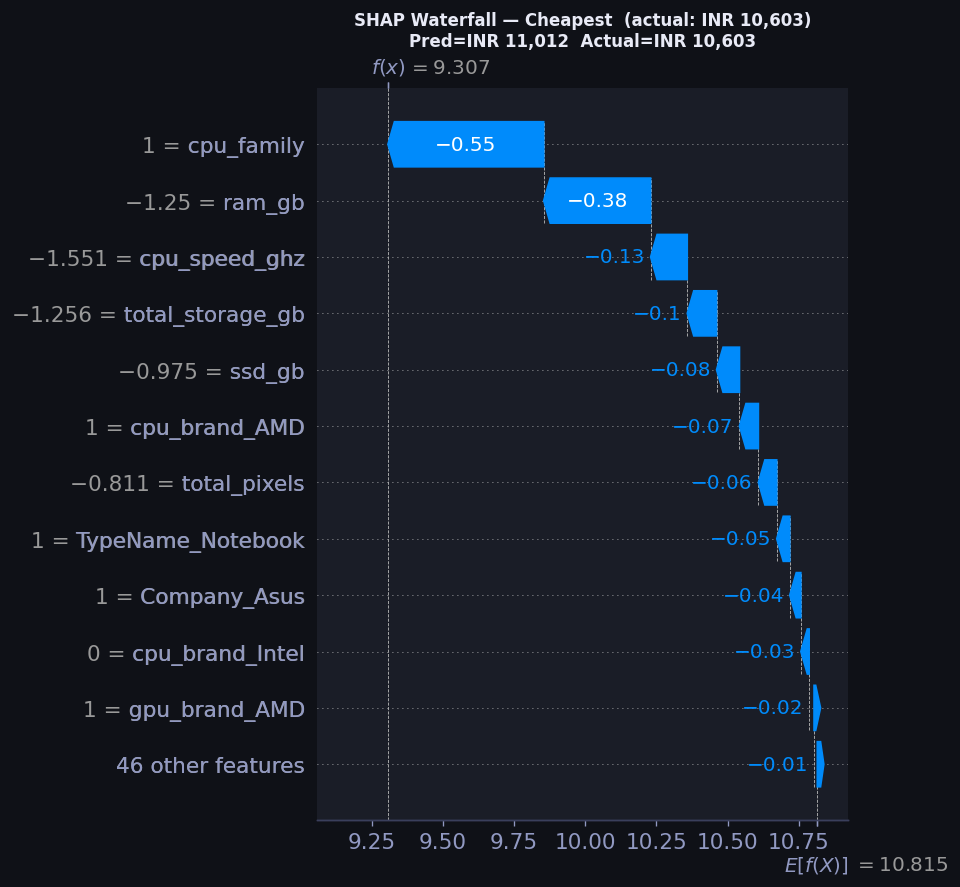


  Median    (actual: INR 49,657)
  Predicted : INR     45,245  |  log=10.720
  Actual    : INR     49,657
  Error     : INR     +4,411  (+8.9%)


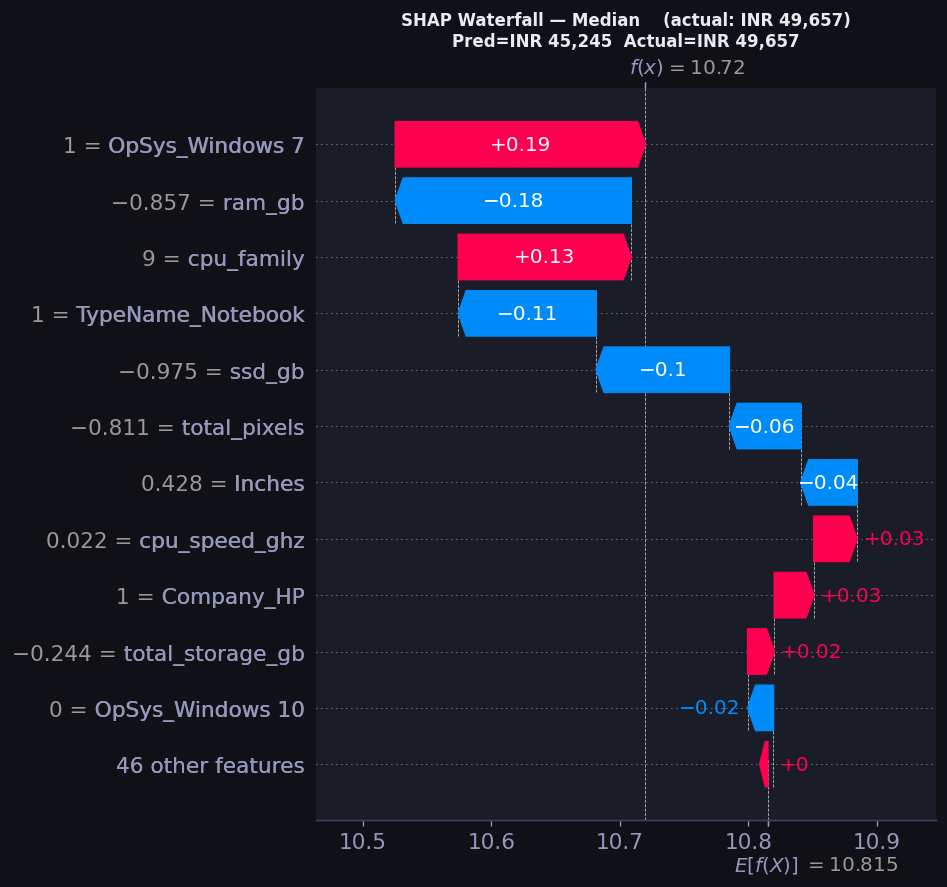


  Most Exp. (actual: INR 324,955)
  Predicted : INR    307,295  |  log=12.636
  Actual    : INR    324,955
  Error     : INR    +17,660  (+5.4%)


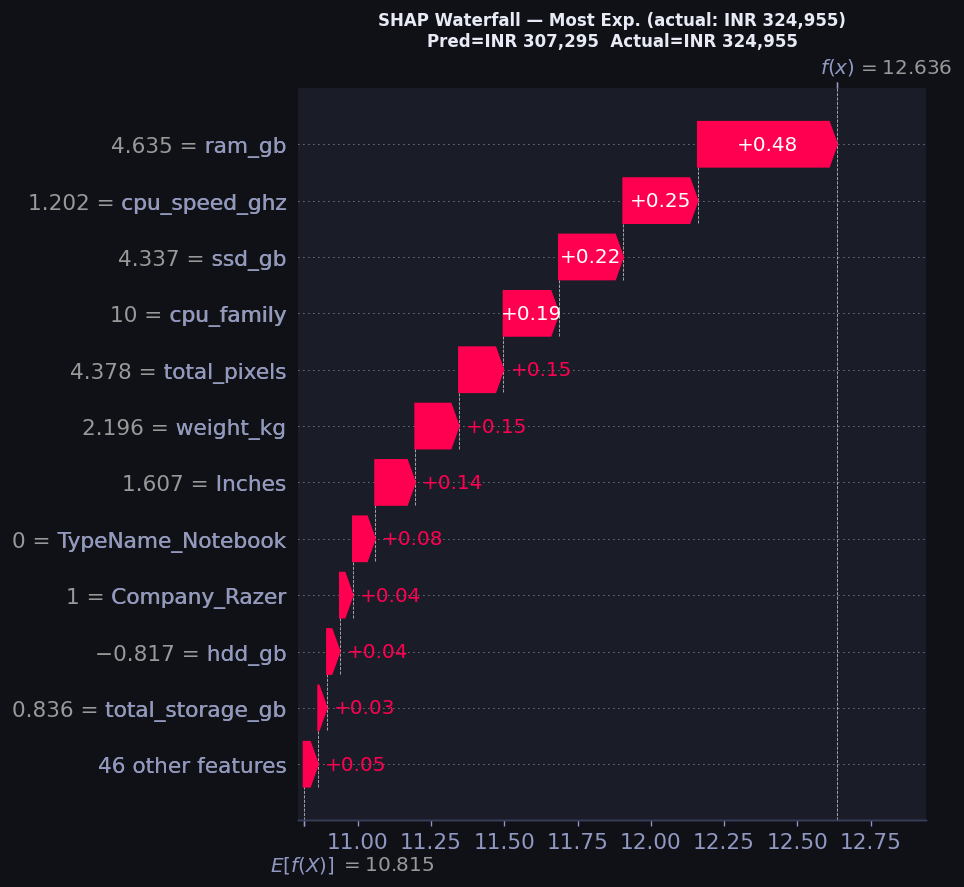


  Worst Err (actual: INR 68,145)
  Predicted : INR    180,347  |  log=12.103
  Actual    : INR     68,145
  Error     : INR   -112,202  (-164.7%)


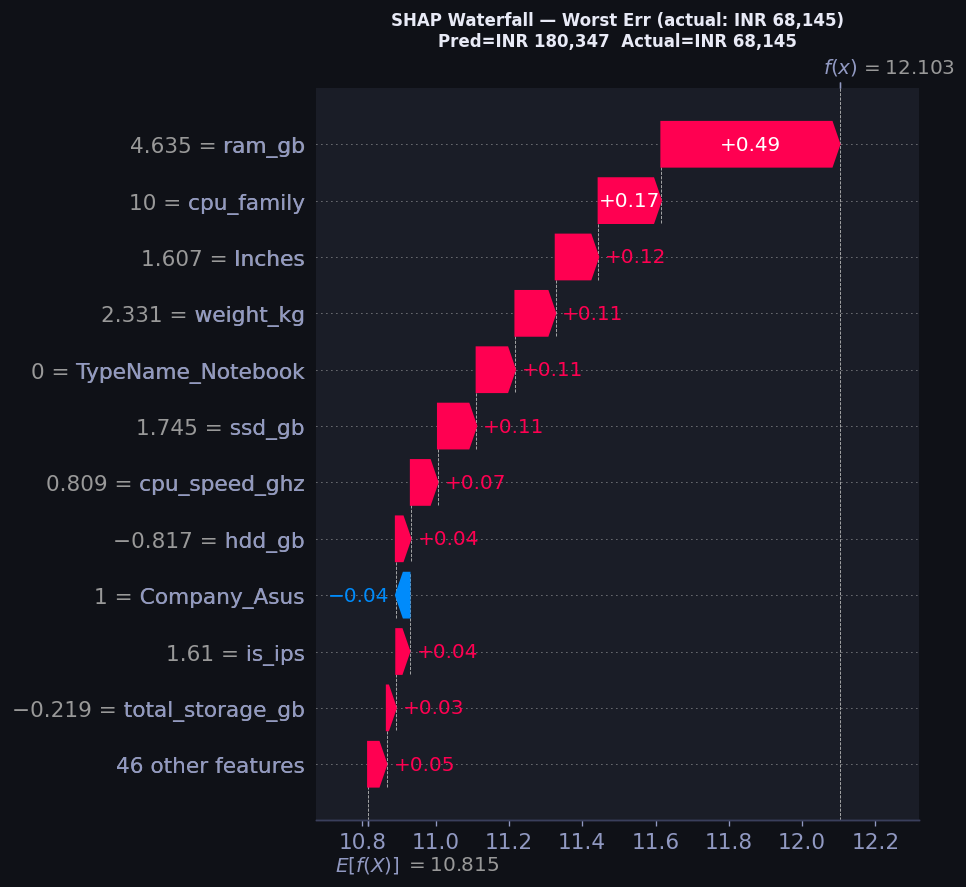

In [7]:
# Select 4 representative examples: cheapest, median-priced, expensive, largest error
cheapest_idx  = y_test.values.argmin()
most_exp_idx  = y_test.values.argmax()
median_idx    = (np.abs(y_test.values - np.median(y_test.values))).argmin()
worst_err_idx = np.abs(residuals).argmax()

examples = [
    (cheapest_idx,  f"Cheapest  (actual: INR {y_true_inr[cheapest_idx]:,.0f})"),
    (median_idx,    f"Median    (actual: INR {y_true_inr[median_idx]:,.0f})"),
    (most_exp_idx,  f"Most Exp. (actual: INR {y_true_inr[most_exp_idx]:,.0f})"),
    (worst_err_idx, f"Worst Err (actual: INR {y_true_inr[worst_err_idx]:,.0f})"),
]

shap_explanation = shap.Explanation(
    values          = shap_values,
    base_values     = explainer.expected_value,
    data            = X_test_transformed,
    feature_names   = feat_names,
)

for row_idx, label in examples:
    pred_inr  = preds_inr[row_idx]
    true_inr  = y_true_inr[row_idx]
    log_pred  = log_preds_test[row_idx]

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"  Predicted : INR {pred_inr:>10,.0f}  |  log={log_pred:.3f}")
    print(f"  Actual    : INR {true_inr:>10,.0f}")
    print(f"  Error     : INR {true_inr-pred_inr:>+10,.0f}  ({(true_inr-pred_inr)/true_inr*100:+.1f}%)")
    print(f"{'='*60}")

    fig = plt.figure(figsize=(10, 4))
    fig.patch.set_facecolor("#0f1117")
    shap.plots.waterfall(shap_explanation[row_idx], max_display=12, show=False)
    ax = plt.gca()
    ax.set_facecolor("#1a1d27")
    ax.set_title(f"SHAP Waterfall — {label}\n"
                 f"Pred=INR {pred_inr:,.0f}  Actual=INR {true_inr:,.0f}",
                 color="#e8eaf6", fontweight="bold", fontsize=10)
    plt.tight_layout()
    plt.show()

---
## 7. Error Analysis — Actual vs Predicted

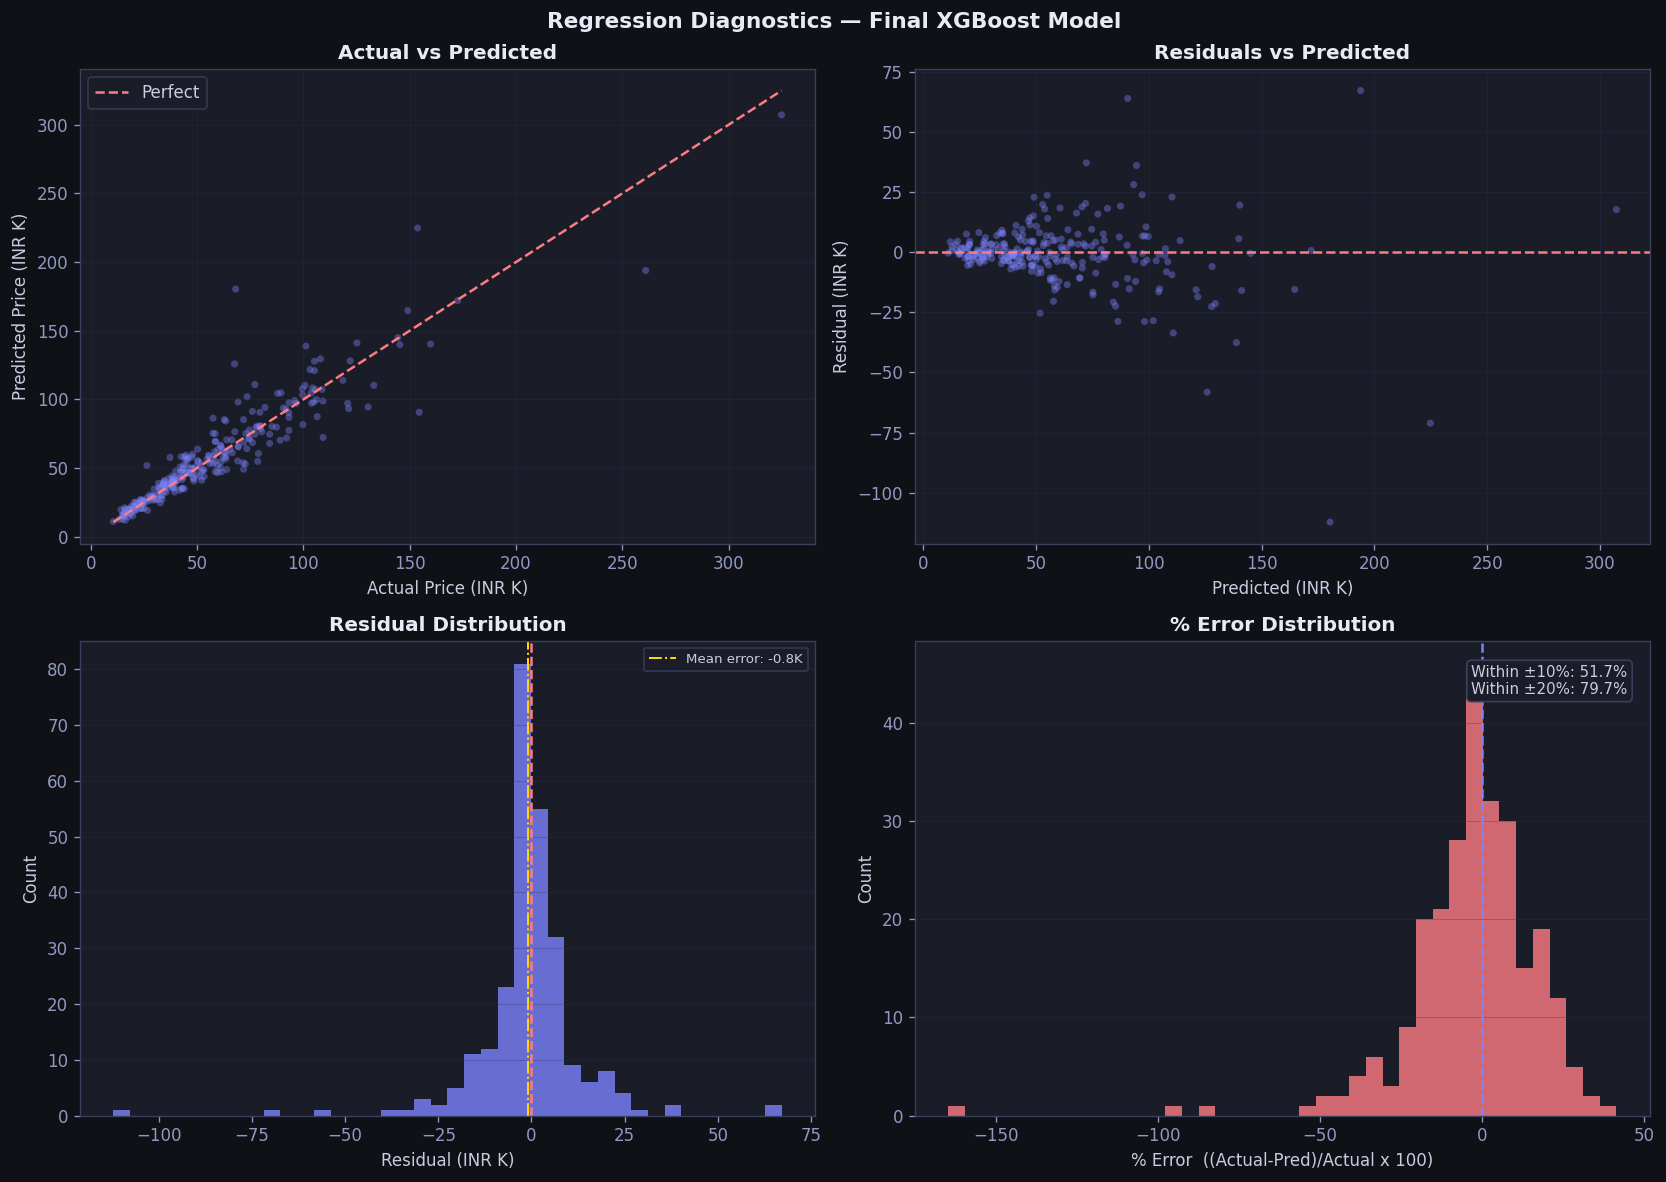

Residual skewness : -1.599
Within ±10%       : 51.7%
Within ±20%       : 79.7%


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Regression Diagnostics — Final XGBoost Model",
             color="#e8eaf6", fontweight="bold", fontsize=13)

# 1. Actual vs Predicted
ax = axes[0, 0]
ax.scatter(y_true_inr/1000, preds_inr/1000, alpha=0.4, s=18,
           color=ACCENT, edgecolors="none")
mn = min(y_true_inr.min(), preds_inr.min()) / 1000
mx = max(y_true_inr.max(), preds_inr.max()) / 1000
ax.plot([mn, mx], [mn, mx], color=HIGHLIGHT, lw=1.5, ls="--", label="Perfect")
ax.set_title("Actual vs Predicted")
ax.set_xlabel("Actual Price (INR K)")
ax.set_ylabel("Predicted Price (INR K)")
ax.legend(); ax.grid(alpha=0.3)

# 2. Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(preds_inr/1000, residuals/1000, alpha=0.4, s=18,
           color=ACCENT, edgecolors="none")
ax.axhline(0, color=HIGHLIGHT, lw=1.5, ls="--")
ax.set_title("Residuals vs Predicted")
ax.set_xlabel("Predicted (INR K)")
ax.set_ylabel("Residual (INR K)")
ax.grid(alpha=0.3)

# 3. Residual histogram
ax = axes[1, 0]
ax.hist(residuals/1000, bins=40, color=ACCENT, edgecolor="none", alpha=0.8)
ax.axvline(0, color=HIGHLIGHT, lw=1.5, ls="--")
ax.axvline(np.mean(residuals)/1000, color="#ffd700", lw=1.2, ls="-.",
           label=f"Mean error: {np.mean(residuals)/1000:+.1f}K")
ax.set_title("Residual Distribution")
ax.set_xlabel("Residual (INR K)")
ax.set_ylabel("Count")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

# 4. % Error distribution
ax = axes[1, 1]
ax.hist(pct_errors, bins=40, color=HIGHLIGHT, edgecolor="none", alpha=0.8)
ax.axvline(0, color=ACCENT, lw=1.5, ls="--")
w10 = (np.abs(pct_errors) <= 10).mean() * 100
w20 = (np.abs(pct_errors) <= 20).mean() * 100
ax.set_title("% Error Distribution")
ax.set_xlabel("% Error  ((Actual-Pred)/Actual x 100)")
ax.set_ylabel("Count")
ax.text(0.97, 0.95, f"Within ±10%: {w10:.1f}%\nWithin ±20%: {w20:.1f}%",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        color="#c8cce0",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#1a1d27", edgecolor="#3a3f5c"))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residual skewness : {pd.Series(residuals).skew():.3f}")
print(f"Within ±10%       : {w10:.1f}%")
print(f"Within ±20%       : {w20:.1f}%")

---
## 8. MAE by Price Range

Price bands are derived from actual dataset quantiles, not arbitrary cutoffs.

Price band thresholds (from training quartiles):
  Budget   : < INR 31,416
  Mid-Low  : INR 31,416 – 52,348
  Mid-High : INR 52,348 – 79,867
  Premium  : > INR 79,867

                  Band  N     R2     MAE    RMSE  Median Actual
    Budget (< INR 31K) 55  0.283  2659.0  4397.0        21498.0
 Mid-Low (INR 31K–52K) 84 -0.267  4988.0  6484.0        41905.0
Mid-High (INR 52K–80K) 67 -5.457 11574.0 19671.0        63563.0
   Premium (> INR 80K) 55  0.727 14787.0 21646.0       103843.0


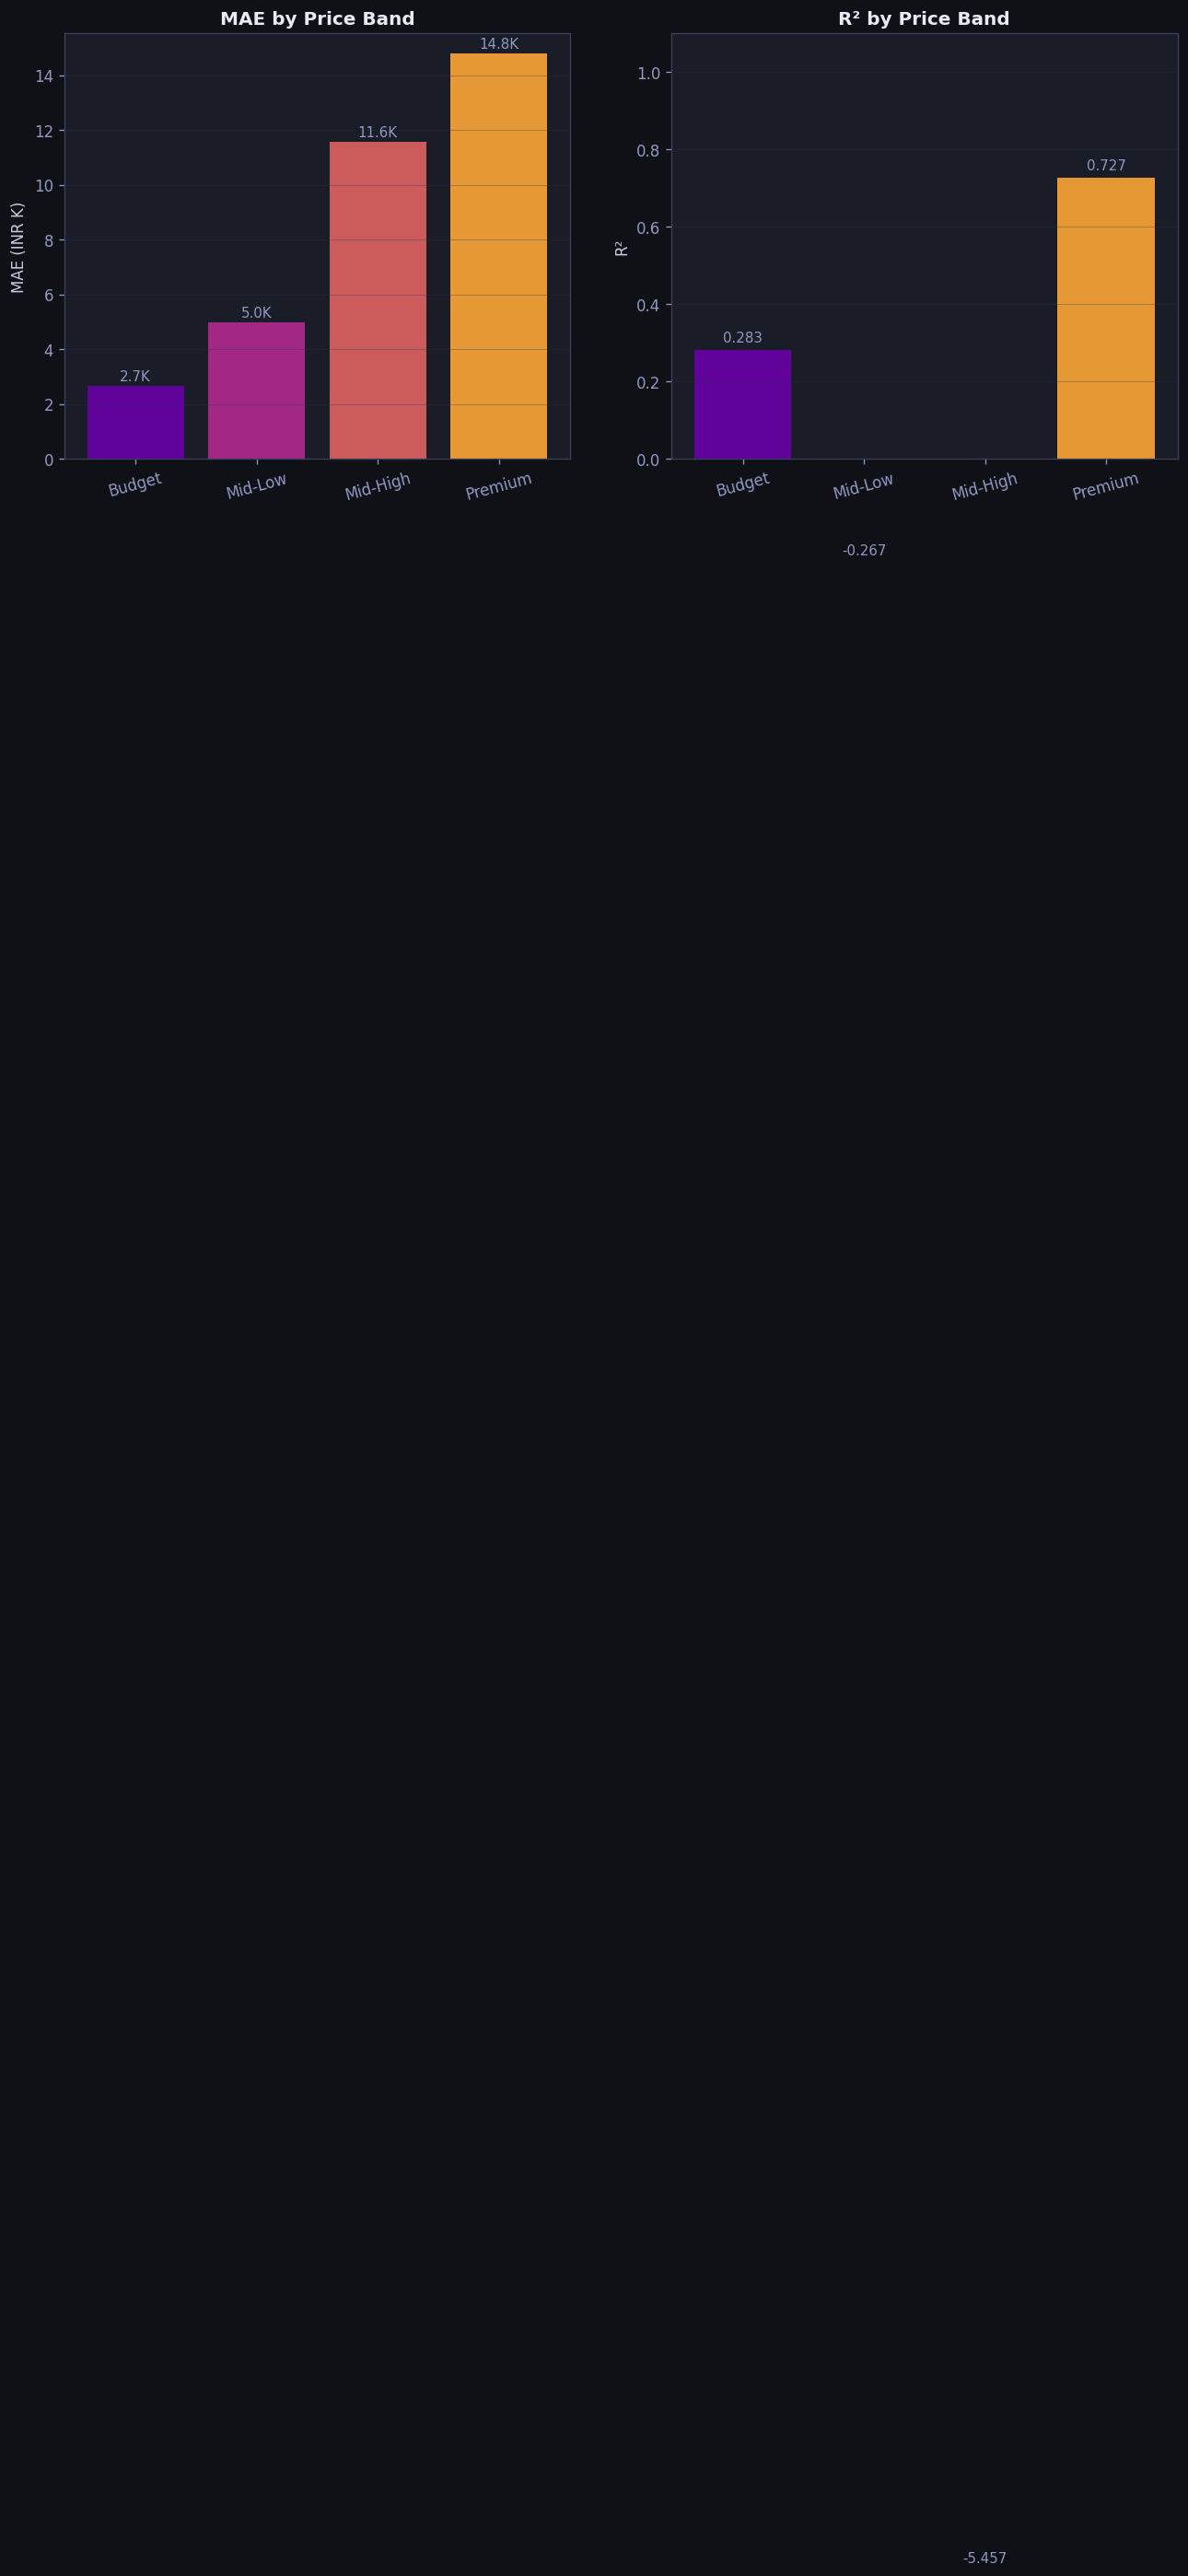

In [9]:
# Define price bands from actual training distribution quartiles
q25 = y_train.quantile(0.25)
q50 = y_train.quantile(0.50)
q75 = y_train.quantile(0.75)

bands = [
    ("Budget",    0,    q25,  f"< INR {q25/1000:.0f}K"),
    ("Mid-Low",   q25,  q50,  f"INR {q25/1000:.0f}K–{q50/1000:.0f}K"),
    ("Mid-High",  q50,  q75,  f"INR {q50/1000:.0f}K–{q75/1000:.0f}K"),
    ("Premium",   q75,  1e9,  f"> INR {q75/1000:.0f}K"),
]

print(f"Price band thresholds (from training quartiles):")
print(f"  Budget   : < INR {q25:,.0f}")
print(f"  Mid-Low  : INR {q25:,.0f} – {q50:,.0f}")
print(f"  Mid-High : INR {q50:,.0f} – {q75:,.0f}")
print(f"  Premium  : > INR {q75:,.0f}\n")

band_stats = []
for bname, lo, hi, label in bands:
    mask = (y_true_inr >= lo) & (y_true_inr < hi)
    if mask.sum() == 0:
        continue
    yr = y_true_inr[mask]
    pr = preds_inr[mask]
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    band_stats.append({
        "Band": f"{bname} ({label})",
        "N": int(mask.sum()),
        "R2":   round(r2_score(yr, pr), 3),
        "MAE":  round(mean_absolute_error(yr, pr), 0),
        "RMSE": round(np.sqrt(mean_squared_error(yr, pr)), 0),
        "Median Actual": round(np.median(yr), 0),
    })

band_df = pd.DataFrame(band_stats)
print(band_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(band_df)))
bars = ax.bar(band_df["Band"].str.split("(").str[0].str.strip(),
              band_df["MAE"] / 1000, color=colors, edgecolor="none", alpha=0.9)
ax.set_title("MAE by Price Band")
ax.set_ylabel("MAE (INR K)")
ax.tick_params(axis="x", rotation=15)
for bar, val in zip(bars, band_df["MAE"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val/1000:.1f}K", ha="center", fontsize=9, color="#9199c2")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
bars2 = ax.bar(band_df["Band"].str.split("(").str[0].str.strip(),
               band_df["R2"], color=colors, edgecolor="none", alpha=0.9)
ax.set_title("R² by Price Band")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=15)
ax.set_ylim(0, 1.1)
for bar, val in zip(bars2, band_df["R2"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontsize=9, color="#9199c2")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Largest Prediction Errors

In [10]:
# Build error analysis DataFrame
err_df = df_test[[
    "Company", "TypeName", "cpu_family", "gpu_brand",
    "ram_gb", "primary_storage_type", "Price"
]].copy()
err_df["Predicted_INR"]  = preds_inr
err_df["Residual_INR"]   = residuals
err_df["Abs_Error_INR"]  = np.abs(residuals)
err_df["Pct_Error"]      = pct_errors

worst20 = err_df.nlargest(20, "Abs_Error_INR")

print("Top 20 Largest Absolute Errors:")
display_cols = ["Company", "TypeName", "cpu_family", "gpu_brand",
                "ram_gb", "Price", "Predicted_INR", "Residual_INR", "Pct_Error"]
print(worst20[display_cols].to_string(index=False))

print("\nCompany distribution in top 20 errors:")
print(worst20["Company"].value_counts().to_string())

print("\nLaptop type distribution in top 20 errors:")
print(worst20["TypeName"].value_counts().to_string())

Top 20 Largest Absolute Errors:
Company           TypeName cpu_family gpu_brand  ram_gb       Price  Predicted_INR   Residual_INR   Pct_Error
   Asus             Gaming    Core i7    Nvidia      32  68145.1200  180347.234375 -112202.114375 -164.651723
   Dell        Workstation    Core i7    Nvidia      16 153705.3408  224797.328125  -71091.987325  -46.252126
 Lenovo           Notebook       Xeon    Nvidia      32 261018.7200  193902.437500   67116.282500   25.713207
     HP        Workstation    Core i7       AMD       8 154458.7200   90600.632812   63858.087188   41.343142
   Asus             Gaming    Core i7    Nvidia      24  67612.3200  125835.859375  -58223.539375  -86.113802
 Lenovo 2 in 1 Convertible    Core i7    Nvidia      16 101178.7200  138804.500000  -37625.780000  -37.187444
   Dell             Gaming    Core i5    Nvidia      16 109277.2800   72241.734375   37035.545625   33.891350
    MSI             Gaming    Core i7    Nvidia      16 130482.7200   94503.593750   359

---
## 10. Segment-Level Performance Analysis

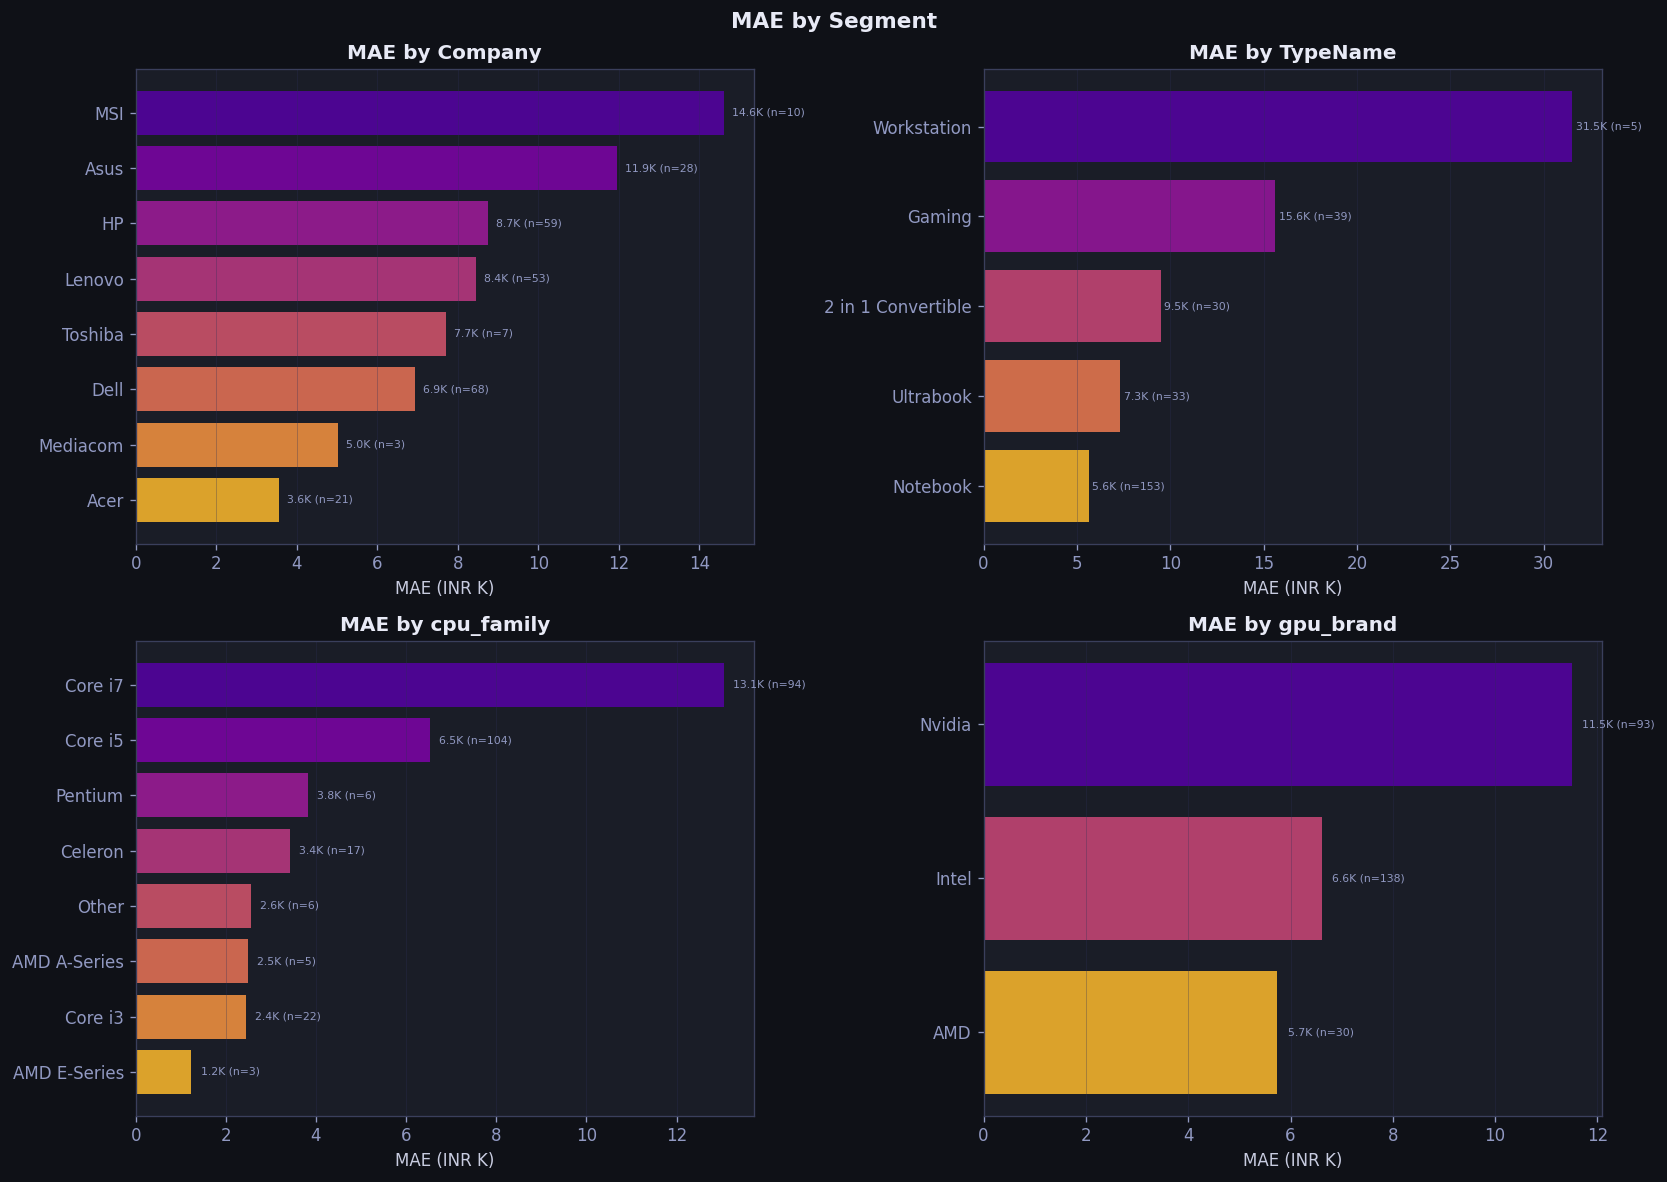

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MAE by Segment", color="#e8eaf6", fontweight="bold", fontsize=13)

segments = [
    ("Company",    axes[0,0]),
    ("TypeName",   axes[0,1]),
    ("cpu_family", axes[1,0]),
    ("gpu_brand",  axes[1,1]),
]

for col, ax in segments:
    seg_stats = []
    for val in err_df[col].unique():
        mask = err_df[col] == val
        if mask.sum() < 3:
            continue
        seg_stats.append({
            col: val,
            "MAE": mean_absolute_error(err_df.loc[mask, "Price"],
                                        err_df.loc[mask, "Predicted_INR"]),
            "N":   int(mask.sum()),
        })
    seg_df = pd.DataFrame(seg_stats).sort_values("MAE", ascending=False)
    colors  = plt.cm.plasma(np.linspace(0.15, 0.85, len(seg_df)))
    bars    = ax.barh(seg_df[col][::-1], seg_df["MAE"][::-1] / 1000,
                      color=colors[::-1], edgecolor="none", alpha=0.85)
    ax.set_title(f"MAE by {col}")
    ax.set_xlabel("MAE (INR K)")
    ax.grid(axis="x", alpha=0.3)
    for bar, (_, row) in zip(bars, seg_df[::-1].iterrows()):
        ax.text(row["MAE"]/1000 + 0.2, bar.get_y() + bar.get_height()/2,
                f"{row['MAE']/1000:.1f}K (n={row['N']})",
                va="center", fontsize=6.5, color="#9199c2")

plt.tight_layout()
plt.show()

---
## 11. Model Limitations Summary

In [12]:
# Auto-derive key findings from actual data
worst_seg_company = (err_df.groupby("Company")["Abs_Error_INR"]
                           .mean().sort_values(ascending=False))
worst_seg_type    = (err_df.groupby("TypeName")["Abs_Error_INR"]
                           .mean().sort_values(ascending=False))

premium_mask  = err_df["Price"] > q75
budget_mask   = err_df["Price"] < q25
premium_mae   = mean_absolute_error(
    err_df.loc[premium_mask, "Price"], err_df.loc[premium_mask, "Predicted_INR"])
budget_mae    = mean_absolute_error(
    err_df.loc[budget_mask, "Price"], err_df.loc[budget_mask, "Predicted_INR"])

print("=" * 60)
print("  MODEL LIMITATIONS & ERROR ANALYSIS SUMMARY")
print("=" * 60)
print(f"\n  Overall Test MAE  : INR {mean_absolute_error(y_true_inr, preds_inr):,.0f}")
print(f"  Overall Test RMSE : INR {np.sqrt(mean_squared_error(y_true_inr, preds_inr)):,.0f}")
print(f"  Overall Test R2   : {r2_score(y_true_inr, preds_inr):.4f}")
print(f"\n  By price segment:")
print(f"    Budget MAE  : INR {budget_mae:,.0f}")
print(f"    Premium MAE : INR {premium_mae:,.0f}")
print(f"    Premium laptops are harder to predict (wider price spread)")
print(f"\n  Hardest companies (by mean abs error, test set):")
for comp, val in worst_seg_company.head(3).items():
    n = (err_df["Company"] == comp).sum()
    print(f"    {comp:15s} : INR {val:>8,.0f}  (n={n})")
print(f"\n  Hardest laptop types (by mean abs error):")
for lt, val in worst_seg_type.head(3).items():
    n = (err_df["TypeName"] == lt).sum()
    print(f"    {lt:20s} : INR {val:>8,.0f}  (n={n})")
print(f"\n  Known limitations:")
print(f"    1. Premium/luxury laptops have higher absolute errors")
print(f"       (model compresses the high end via log transform)")
print(f"    2. Rare brands (n<5 in test) show higher variance")
print(f"    3. Workstations are a small, heterogeneous segment")
print(f"    4. CPU/GPU string matching may miss niche configurations")
print(f"    5. No temporal data — price inflation not captured")
print("=" * 60)

  MODEL LIMITATIONS & ERROR ANALYSIS SUMMARY

  Overall Test MAE  : INR 8,253
  Overall Test RMSE : INR 14,686
  Overall Test R2   : 0.8504

  By price segment:
    Budget MAE  : INR 2,659
    Premium MAE : INR 15,308
    Premium laptops are harder to predict (wider price spread)

  Hardest companies (by mean abs error, test set):
    Razer           : INR   17,660  (n=1)
    MSI             : INR   14,618  (n=10)
    Xiaomi          : INR   12,253  (n=2)

  Hardest laptop types (by mean abs error):
    Workstation          : INR   31,531  (n=5)
    Gaming               : INR   15,603  (n=39)
    2 in 1 Convertible   : INR    9,489  (n=30)

  Known limitations:
    1. Premium/luxury laptops have higher absolute errors
       (model compresses the high end via log transform)
    2. Rare brands (n<5 in test) show higher variance
    3. Workstations are a small, heterogeneous segment
    4. CPU/GPU string matching may miss niche configurations
    5. No temporal data — price inflation not

---
*End of Interpretation Notebook — `03_model_interpretation.ipynb`*